# Case study E1: the Fatrop hanging chain

The Fatrop paper (Vanroye et al., IROS 2023) times Fatrop, acados and IPOPT on OCPs built with
rockit and CasADi. For its two hanging-chain MPC problems the authors could not compile CasADi's C
("compilation failed due to insufficient available memory"), so the oracles ran in CasADi's virtual
machine and function evaluation was left out of the reported times.

This notebook reproduces those two problems with the authors' own code and then puts Scaly's oracles
into the same solvers:

- **the problem**: the chain written in Scaly, solved here by IPOPT and by Fatrop;
- **the comparison**: every solver and oracle provider in fresh processes (`compare.py`);
- **the sweep**: IPOPT's two kernels as the chain grows, Scaly against three CasADi encodings (`sweep.py`).

The Scaly cells run in a few seconds. The baseline cells need rockit (`uv run --with
rockit-meco==0.6.7`) and take tens of minutes, because compiling CasADi's C for these problems
takes minutes; they are off by default (`RUN_BASELINES`) and the recorded results in `results/` are
shown instead. The full write-up is `internal/notes/case_study_e1_report.html`.

In [1]:
import json
import subprocess
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

HERE = Path.cwd()
sys.path.insert(0, str(HERE))
sys.path.insert(0, str(HERE.parents[1] / "notebooks"))

import plotstyle
import scaly as sc

import fatrop_dropin
import scaly_impl

plotstyle.use()
RUN_BASELINES = False  # True reruns the CasADi baselines and the sweep: tens of minutes, needs rockit
RESULTS = HERE / "results"

## The problem

`no_masses = 6` masses on springs between a fixed ground point and an actuated end mass whose velocity
is the control $u$, $|u| \le 1$. In 2D the state is 26 numbers (7 positions and 6 velocities), in 3D
39. Each link pulls with $D (1 - L / \lVert d \rVert)\, d$ for $d$ the difference of its end points,
and gravity acts on the second axis. Multiple shooting over 25 intervals of one RK4 step each, over
$T = 4$ s in 2D and $T = 2$ s in 3D:

$$\min \sum_{k<N} 25\,\lVert p_{\text{end},k} - x_{\text{end}} \rVert^2 + \sum_i \lVert v_{i,k} \rVert^2 + 0.01\,\lVert u_k \rVert^2
\quad \text{s.t.}\quad x_{k+1} = F(x_k, u_k),\; x_0 = \bar x_0,\; -1 \le u_k \le 1.$$

`scaly_impl.py` writes this with the link force `vmap`ped over the chain inside the model, `si.rk4`
for $F$, and the gap and the stage cost `vmap`ped over the horizon. The variables, rows and initial
guess are laid out as rockit lays them out, so IPOPT sees the same problem.

In [2]:
t0 = time.perf_counter()
b = scaly_impl.build(2)
problem = b["problem"]
ipopt = sc.opt.solver(problem, sc.opt.IPOPT(options=scaly_impl.IPOPT_OPTIONS), name="nb_chain2d_ipopt")
x0 = scaly_impl.initial_state(2)
z0 = scaly_impl.initial_guess(2, 6, b["horizon"])
zeros = (np.zeros(b["n_var"]), np.zeros(problem.n_eq), np.zeros(problem.n_ineq))
z, *_ = ipopt(z0, *zeros, x0)
st = sc.opt.solver_stats(ipopt)
print(f"{b['n_var']} variables, {problem.n_eq} equalities, {problem.n_ineq} inequalities; built and compiled in {time.perf_counter() - t0:.1f} s")
print(f"IPOPT: {st.iter} iterations, {st.to_solver_status().name}, {1e3 * st.t_total:.1f} ms, of which oracles {1e3 * st.t_fe:.1f} ms")

726 variables, 676 equalities, 50 inequalities; built and compiled in 1.7 s
IPOPT: 14 iterations, OK, 28.0 ms, of which oracles 7.2 ms


The optimal plan pulls the end mass towards $x_{\text{end}} = (1, 0)$ at full speed while the chain
swings. Each panel below is the chain at one shooting node.

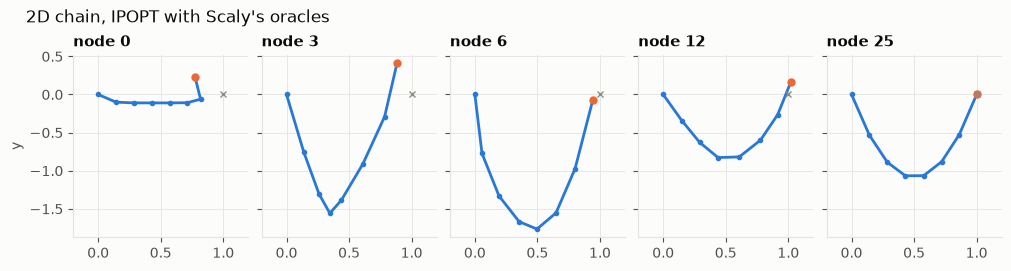

In [3]:
nx, nu, N = b["nx"], b["nu"], b["horizon"]
states = np.vstack([z[: N * (nx + nu)].reshape(N, nx + nu)[:, :nx], z[N * (nx + nu) :]])
fig, axes = plt.subplots(1, 5, figsize=(10, 2.6), sharey=True)
for ax, k in zip(axes, [0, 3, 6, 12, 25]):
  pos = np.vstack([np.zeros(2), states[k, :14].reshape(7, 2)])
  ax.plot(pos[:, 0], pos[:, 1], "-o", markersize=3)
  ax.plot(*pos[-1], "o", color=plotstyle.ORANGE)
  ax.plot(1.0, 0.0, "x", color=plotstyle.NEUTRAL)
  ax.set_title(f"node {k}")
  ax.set_xlim(-0.2, 1.2)
axes[0].set_ylabel("y")
fig.suptitle("2D chain, IPOPT with Scaly's oracles", x=0.02, ha="left")
plt.show()

## Fatrop with Scaly's oracles

CasADi's `fatrop` plugin drives libfatrop through Fatrop's C interface, evaluating CasADi's
whole-NLP oracles and scattering them into per-stage blocks. `fatrop_scaly.c` fills the same
interface from five Scaly Functions (objective, gradient, dynamics residual, stage Jacobians
$[\partial F/\partial(u,x),\ F - x_{k+1}]$ and stage Lagrangian Hessians) and links the same
`libfatrop` from the CasADi wheel. The solver and its linear algebra are identical; only the oracles
change. Fatrop takes 13 iterations on the 2D chain with CasADi's oracles, as in the study.

In [4]:
build_dir = HERE / "build" / "notebook"
lib, info = fatrop_dropin.build(2, build_dir / "2d")
solve = fatrop_dropin.solver(lib, 2, options={"tol": 1e-8})
w0 = fatrop_dropin.to_fatrop(z0, nx, nu, N)
runs = [solve(x0, w0)[1] for _ in range(20)]
w, last = solve(x0, w0)
best = min(runs, key=lambda r: r["wall"])
z_fatrop = fatrop_dropin.from_fatrop(w, nx, nu, N)
print(f"generated in {info['t_generate']:.2f} s, compiled in {info['t_compile']:.2f} s")
print(f"Fatrop: {last['iterations']} iterations, solve {1e3 * best['wall']:.2f} ms, oracles {1e3 * best['t_oracle']:.2f} ms ({best['n_oracle']} calls)")
print(f"largest difference from the IPOPT solution: {np.max(np.abs(z_fatrop - z)):.1e} (both relax |u| <= 1 by 1e-8)")

generated in 0.92 s, compiled in 1.38 s
Fatrop: 13 iterations, solve 5.12 ms, oracles 2.70 ms (70 calls)
largest difference from the IPOPT solution: 2.9e-08 (both relax |u| <= 1 by 1e-8)


The generated C of the Hessian oracle's entry point: one loop over the 25 stages, each iteration
calling the stage function that evaluates $\nabla^2 (s\,\ell_k + \lambda^\top F_k)$ through the RK4
step, whatever the horizon. (Long constant tables are cut at 120 characters.)

In [5]:
src = next((build_dir / "2d").glob("fs_hesss_*.c")).read_text()
start = src.index("int fs_hesss_")
body = src[start:].splitlines()
print("\n".join(line if len(line) <= 120 else line[:117] + "..." for line in body[: body.index("}") + 1]))
print(f"\n{len(src.splitlines())} lines in the file, stage functions included")

int fs_hesss_2d_M6_N25(const double** arg, double** res, int* iw, double* w, int mem) {
  (void)iw;
  (void)mem;
  if (!arg || !res) return SCALY_ERR_NULL_ABI;
  (void)w;
  if (!arg[0]) return SCALY_ERR_NULL_INPUT;
  if (!arg[1]) return SCALY_ERR_NULL_INPUT;
  if (!arg[2]) return SCALY_ERR_NULL_INPUT;
  if (!res[0]) return SCALY_ERR_NULL_RESULT;
  double s0[2];
  double s1[56];
  double s2[12];
  double s3[728];
  double s4[2];
  double s5[728];
  fs_hess_2d_M6_N25_hoist_2_raw(arg[2], s0, s1, s2, s3, s4, s5, NULL);
  for (long long it_fs_hesss_2d_M6_N25 = 0; it_fs_hesss_2d_M6_N25 < 25; ++it_fs_hesss_2d_M6_N25) {
    fs_hess_2d_M6_N25_hoisted_2_raw((arg[0] + (28 * it_fs_hesss_2d_M6_N25)), (arg[1] + (26 * it_fs_hesss_2d_M6_N25)),...
  }
  return SCALY_SUCCESS;
}

3498 lines in the file, stage functions included


## The comparison

`compare.py` runs every variant in its own fresh processes: CasADi's Fatrop and IPOPT with the
oracles in its virtual machine (the paper's fallback) and compiled with the flags Scaly's JIT uses,
then Scaly's IPOPT, Fatrop with Scaly's oracles, and Scaly's SQP. It keeps the fastest of five
processes (one for the compiled CasADi rows, whose compile takes minutes).

In [6]:
if RUN_BASELINES:
  cmd = ["uv", "run", "--with", "rockit-meco==0.6.7", str(HERE / "compare.py"), "--out", str(RESULTS / "solve.json")]
  subprocess.run(["sh", str(HERE / "baseline" / "setup.sh")], check=True)
  subprocess.run(cmd, check=True)
solve_results = json.loads((RESULTS / "solve.json").read_text())

VARIANTS = [
  ("casadi:fatrop:vm", "Fatrop, CasADi VM"),
  ("casadi:fatrop:jit", "Fatrop, CasADi C"),
  ("scaly:fatrop:scaly", "Fatrop, Scaly C"),
  ("casadi:ipopt:vm", "IPOPT, CasADi VM"),
  ("casadi:ipopt:jit", "IPOPT, CasADi C"),
  ("scaly:ipopt:scaly", "IPOPT, Scaly C"),
  ("scaly:sqp:scaly", "Scaly SQP + PIQP"),
]
print(f"{'':22} {'iter':>4} {'solve ms':>9} {'FE ms':>7} {'compile s':>9} {'compiler GB':>11}   agreement")
for dim in (2, 3):
  for key, label in VARIANTS:
    r = solve_results[f"{dim}d:{key}"]
    print(
      f"{dim}D {label:19} {r['iterations']:>4} {1e3 * r['wall_min']:>9.2f} {1e3 * r['fe_at_min']:>7.2f} {r['compile_wall']:>9.1f} "
      f"{r['compile_peak_rss_bytes'] / 1e9:>11.2f}   {r['agreement']:.0e}"
    )

                       iter  solve ms   FE ms compile s compiler GB   agreement
2D Fatrop, CasADi VM     13     24.61   21.41       0.0        0.00   3e-08
2D Fatrop, CasADi C      13      6.97    3.90      72.7        2.91   3e-08
2D Fatrop, Scaly C       13      4.97    2.63       1.4        0.12   3e-08
2D IPOPT, CasADi VM      14     42.09   23.03       0.0        0.00   0e+00
2D IPOPT, CasADi C       14     22.03    2.91      51.4        2.55   0e+00
2D IPOPT, Scaly C        14     24.27    5.55       3.3        0.18   4e-15
2D Scaly SQP + PIQP       4     22.98    1.67       3.5        0.23   2e-06
3D Fatrop, CasADi VM     14     51.28   43.61       0.0        0.00   3e-07
3D Fatrop, CasADi C      14     16.23    8.59     267.0        5.27   3e-07
3D Fatrop, Scaly C       14     15.91    9.81       2.0        0.10   3e-07
3D IPOPT, CasADi VM      14     90.03   45.09       0.0        0.00   0e+00
3D IPOPT, CasADi C       14     56.36   10.09     180.9        4.70   0e+00
3D IPOPT

Each bar splits one solve into function evaluation (dark) and everything else (light). The two IPOPT
builds differ (CasADi's 3.14.11 against Scaly's 3.14.19), so only their function evaluation compares.

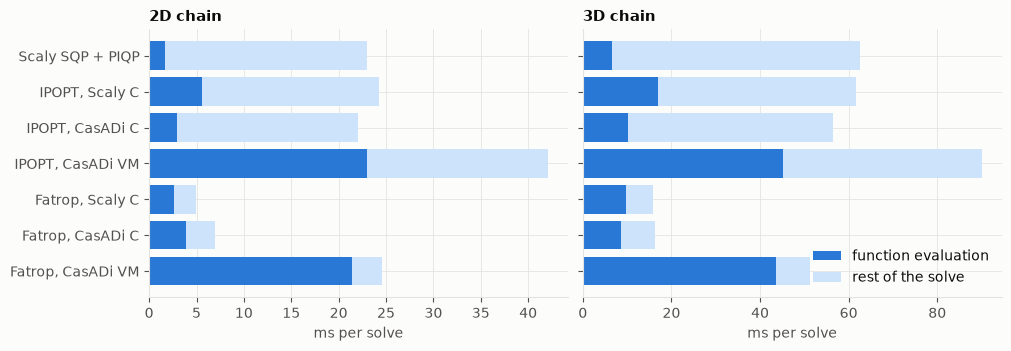

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), sharey=True)
for ax, dim in zip(axes, (2, 3)):
  labels = [label for _, label in VARIANTS]
  fe = np.array([1e3 * solve_results[f"{dim}d:{k}"]["fe_at_min"] for k, _ in VARIANTS])
  total = np.array([1e3 * solve_results[f"{dim}d:{k}"]["wall_min"] for k, _ in VARIANTS])
  y = np.arange(len(labels))
  ax.barh(y, fe, color=plotstyle.BLUE, label="function evaluation")
  ax.barh(y, total - fe, left=fe, color="#cde2fb", label="rest of the solve")
  ax.set_yticks(y, labels)
  ax.invert_yaxis()
  ax.set_xlabel("ms per solve")
  ax.set_title(f"{dim}D chain")
axes[1].legend(loc="lower right")
plt.show()

## What the compile costs

The paper's failure, measured: the compiled CasADi rows compile on this 64 GB machine, but one `cc`
process peaks at 2.5 to 5.3 GB and runs for up to 4.5 minutes. Scaly compiles the same oracle sets in
seconds.

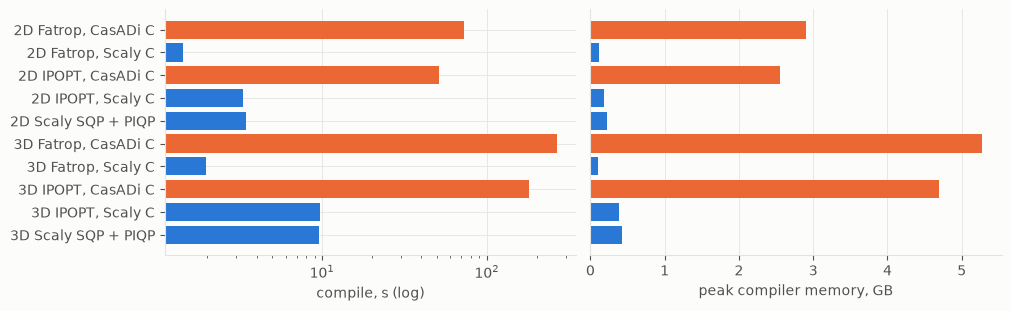

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.0))
rows = [(f"{d}D {label}", solve_results[f"{d}d:{k}"]) for d in (2, 3) for k, label in VARIANTS if "VM" not in label]
labels = [name for name, _ in rows]
colors = [plotstyle.ORANGE if "CasADi" in name else plotstyle.BLUE for name in labels]
axes[0].barh(labels, [r["compile_wall"] for _, r in rows], color=colors)
axes[0].set_xscale("log")
axes[0].set_xlabel("compile, s (log)")
axes[1].barh(labels, [r["compile_peak_rss_bytes"] / 1e9 for _, r in rows], color=colors)
axes[1].set_xlabel("peak compiler memory, GB")
axes[1].set_yticks([])
for ax in axes:
  ax.invert_yaxis()
plt.show()

## The size sweep

The 3D chain at $N = 25$ from 3 to 15 masses: IPOPT's Lagrangian Hessian and constraint Jacobian,
each built in a fresh process, compiled with a 180 s budget and timed from C. A backend that misses the
budget is not tried at larger sizes. "Scaly (stage)" is the Fatrop drop-in's layout of the same
derivatives.

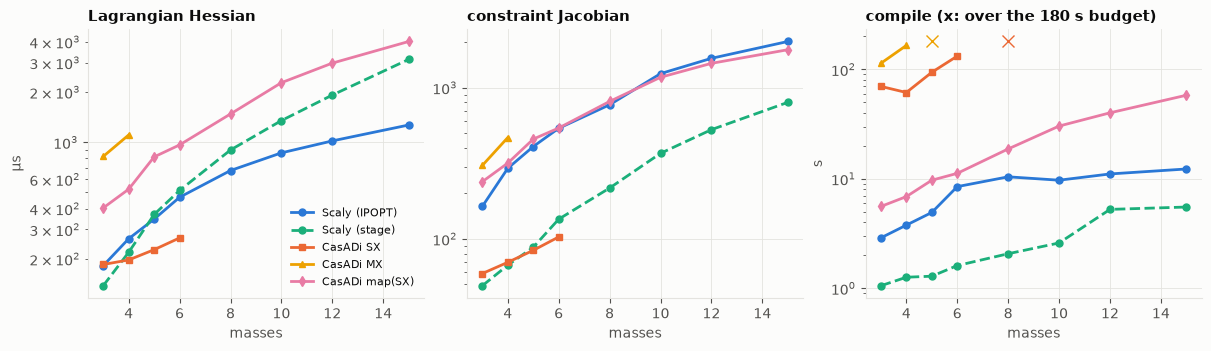

In [9]:
if RUN_BASELINES:
  subprocess.run(["uv", "run", "--with", "rockit-meco==0.6.7", str(HERE / "sweep.py"), "--dim", "3", "--out", str(RESULTS / "sweep_3d.json")], check=True)
sweep = json.loads((RESULTS / "sweep_3d.json").read_text())
names = {"scaly": "Scaly (IPOPT)", "scaly_stage": "Scaly (stage)", "casadi_sx": "CasADi SX", "casadi_mx": "CasADi MX", "casadi_map": "CasADi map(SX)"}
styles = {"scaly": ("-o", plotstyle.BLUE), "scaly_stage": ("--o", plotstyle.AQUA), "casadi_sx": ("-s", plotstyle.ORANGE), "casadi_mx": ("-^", plotstyle.YELLOW), "casadi_map": ("-d", plotstyle.MAGENTA)}
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for backend, name in names.items():
  ok = sorted((r for r in sweep if r["backend"] == backend and r.get("ok")), key=lambda r: r["masses"])
  m = [r["masses"] for r in ok]
  style, color = styles[backend]
  axes[0].plot(m, [1e6 * r["hess_best"] for r in ok], style, color=color, label=name)
  axes[1].plot(m, [1e6 * r["jac_best"] for r in ok], style, color=color)
  axes[2].plot(m, [r["compile_wall"] for r in ok], style, color=color)
  failed = [r["masses"] for r in sweep if r["backend"] == backend and not r.get("ok")]
  if failed:
    axes[2].plot(failed, [180] * len(failed), "x", color=color, markersize=9)
axes[0].set_title("Lagrangian Hessian")
axes[1].set_title("constraint Jacobian")
axes[2].set_title("compile (x: over the 180 s budget)")
for ax in axes:
  ax.set_yscale("log")
  ax.set_xlabel("masses")
axes[0].set_ylabel("µs")
axes[2].set_ylabel("s")
axes[0].legend(fontsize=8)
plt.show()

## What it shows

- The drop-ins are exact: Fatrop and IPOPT take the same iterations with Scaly's oracles as with
  CasADi's (13 and 14 in 2D, 14 and 14 in 3D) and reach the same solutions to 7e-15.
- The compile the paper could not do costs CasADi 51 to 267 s and 2.5 to 5.3 GB; Scaly takes 1.4 to
  9.7 s and at most 0.4 GB.
- While CasADi's SX encoding compiles, its kernels are the fastest (up to 1.75x Scaly's Hessian at 6
  masses in 3D). From 8 masses it misses the budget, and Scaly is 2.2 to 3.7x faster than the best
  CasADi encoding that still compiles.
- Two Scaly costs show up: IPOPT's oracles recombine per-stage derivatives through dense seed
  contractions (2.5 to 4.6x the stage Jacobian), and the dense stage Hessian does not exploit the
  chain's structure. Both are in `internal/todo.md` (CS-2, CS-3).